# 10. 시계열 패널 분석 — 연도별 변화 추적 및 고정효과 모델

> **목적:** 모델링 v2(횡단면 분석)를 시간 차원으로 확장
> - 2019~2024년 보호소×연도 패널 데이터 구축
> - 연도별 입양률 추이와 수렴/발산 분석
> - 고정효과 모델로 "시간에 따른 변화" 포착
> - Granger 인과검정, DID 분석

In [1]:
# ── 환경 설정 ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, '02_outputs', 'data')
FIG_DIR = os.path.join(BASE_DIR, '02_outputs', 'figures', 'panel')
os.makedirs(FIG_DIR, exist_ok=True)

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"FIG_DIR:  {FIG_DIR}")


BASE_DIR: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound
DATA_DIR: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data
FIG_DIR:  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/panel


In [2]:
# ── 데이터 로드 ──
df_animals = pd.read_csv(os.path.join(DATA_DIR, 'shelter_animals_enhanced.csv'))
df_socio = pd.read_csv(os.path.join(DATA_DIR, 'socioeconomic_panel_v4.csv'))
df_region = pd.read_csv(os.path.join(DATA_DIR, 'agg_region_yearly.csv'))
df_cluster = pd.read_csv(os.path.join(DATA_DIR, 'shelter_clustering_v2_result.csv'))

print(f"shelter_animals_enhanced: {df_animals.shape}")
print(f"socioeconomic_panel_v4:   {df_socio.shape}")
print(f"agg_region_yearly:        {df_region.shape}")
print(f"shelter_clustering_v2:    {df_cluster.shape}")
print(f"\n연도 범위 (보호동물): {sorted(df_animals['접수년도'].unique())}")
print(f"연도 범위 (사회경제): {sorted(df_socio['연도'].unique())}")


shelter_animals_enhanced: (789874, 32)
socioeconomic_panel_v4:   (1794, 15)
agg_region_yearly:        (119, 11)
shelter_clustering_v2:    (564, 22)

연도 범위 (보호동물): [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
연도 범위 (사회경제): [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 2. 보호소×연도 패널 데이터 구축

shelter_animals_enhanced.csv (789,874건)에서 보호소×연도별 집계 후, 사회경제 데이터와 클러스터 라벨을 병합합니다.

In [3]:
# ── 보호소×연도별 집계 ──
df_a = df_animals[df_animals['접수년도'].between(2019, 2024)].copy()
print(f"2019-2024 데이터: {len(df_a):,}행")

# 종료사유별 집계를 위한 더미 생성
df_a['안락사여부'] = (df_a['종료사유_정제'] == '안락사').astype(int)
df_a['자연사여부'] = (df_a['종료사유_정제'] == '자연사').astype(int)
df_a['반환여부'] = (df_a['종료사유_정제'] == '반환').astype(int)
df_a['개여부'] = (df_a['동물종류'] == '개').astype(int)

# 보호기간 결측 처리
df_a['보호기간일'] = df_a['보호기간일'].fillna(0)

# 집계
agg = df_a.groupby(['보호소명', '시도', '시군구', '접수년도']).agg(
    총건수=('입양여부', 'count'),
    입양건수=('입양여부', 'sum'),
    안락사건수=('안락사여부', 'sum'),
    자연사건수=('자연사여부', 'sum'),
    반환건수=('반환여부', 'sum'),
    개비율=('개여부', 'mean'),
    평균보호기간=('보호기간일', 'mean'),
).reset_index()

agg['개비율'] = agg['개비율'] * 100
agg['입양률'] = agg['입양건수'] / agg['총건수'] * 100
agg['안락사율'] = agg['안락사건수'] / agg['총건수'] * 100
agg['자연사율'] = agg['자연사건수'] / agg['총건수'] * 100

print(f"보호소×연도 패널: {agg.shape}")
print(f"보호소 수: {agg['보호소명'].nunique()}")
print(f"연도 범위: {sorted(agg['접수년도'].unique())}")
print(f"\n기초통계:")
display(agg[['총건수','입양률','안락사율','자연사율','개비율','평균보호기간']].describe().round(2))


2019-2024 데이터: 704,385행


보호소×연도 패널: (2096, 14)
보호소 수: 434
연도 범위: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

기초통계:


,총건수,입양률,안락사율,자연사율,개비율,평균보호기간
count,2096.00,2096.00,2096.00,2096.00,2096.00,2096.00
mean,336.06,35.18,19.60,26.39,67.31,10.54
std,446.35,22.18,21.49,19.89,29.60,1.84
min,1.00,0.00,0.00,0.00,0.00,1.57
25%,82.75,20.00,1.64,10.54,45.32,10.40
50%,217.50,30.30,12.70,23.72,73.33,10.56
75%,435.00,47.24,30.09,38.73,95.15,10.68
max,7305.00,100.00,100.00,100.00,100.00,56.52


In [4]:
# ── 사회경제 데이터 병합 ──
# 시군구 × 연도 키로 병합
panel = agg.merge(
    df_socio[['시군구', '연도', '인구밀도', '재정자립도', '고령화율', '1인가구비율']],
    left_on=['시군구', '접수년도'],
    right_on=['시군구', '연도'],
    how='left'
)

matched = panel['인구밀도'].notna().sum()
total = len(panel)
print(f"사회경제 병합: {matched}/{total} ({matched/total*100:.1f}%) 매칭")

# 연도 컬럼 정리
if '연도' in panel.columns:
    panel.drop(columns=['연도'], inplace=True)


사회경제 병합: 3277/3552 (92.3%) 매칭


In [5]:
# ── 클러스터 라벨 + 수의사유무 병합 ──
panel = panel.merge(
    df_cluster[['보호소명', 'cluster_v2', 'cluster_v2_label', '수의사유무']],
    on='보호소명', how='left'
)

# 패널 기초통계
n_shelter = panel['보호소명'].nunique()
n_year = panel['접수년도'].nunique()
obs_per_shelter = panel.groupby('보호소명').size()
balanced = (obs_per_shelter == n_year).all()

print(f"패널 구조:")
print(f"  보호소 수: {n_shelter}")
print(f"  연도 수: {n_year}")
print(f"  총 관측치: {len(panel):,}")
print(f"  균형 패널 여부: {'예' if balanced else '아니오'}")
print(f"  보호소별 관측 횟수: 평균 {obs_per_shelter.mean():.1f}, 범위 {obs_per_shelter.min()}~{obs_per_shelter.max()}")

# 클러스터 분포
print(f"\n클러스터 분포 (보호소 수):")
print(panel.groupby('cluster_v2_label')['보호소명'].nunique())

# 패널 CSV 저장
panel_path = os.path.join(DATA_DIR, 'shelter_yearly_panel.csv')
panel.to_csv(panel_path, index=False, encoding='utf-8-sig')
print(f"\n패널 저장: {panel_path}")


패널 구조:
  보호소 수: 434
  연도 수: 6
  총 관측치: 12,853
  균형 패널 여부: 아니오
  보호소별 관측 횟수: 평균 29.6, 범위 1~5887

클러스터 분포 (보호소 수):
cluster_v2_label
C0: 고안락사형    243
C1: 균형관리형     56
C2: 균형관리형     21
C3: 고입양형     134
Name: 보호소명, dtype: int64



패널 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data/shelter_yearly_panel.csv


## 3. 패널 EDA — 연도별 추이 분석

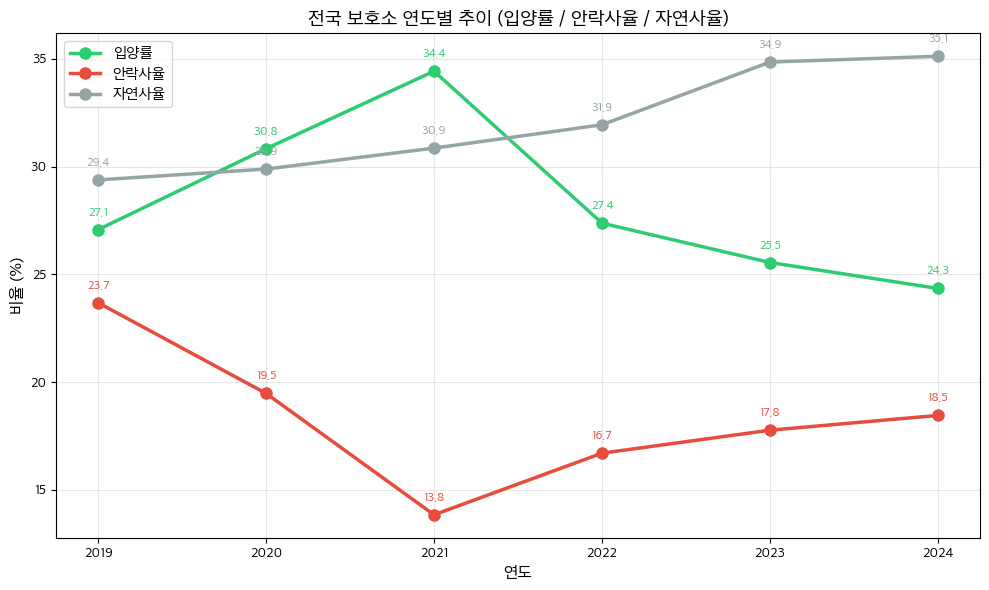

저장: national_yearly_trend.png


In [6]:
# ── 전국 연도별 추이 ──
yearly = panel.groupby('접수년도')[['입양률', '안락사율', '자연사율']].mean()

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'입양률': '#2ecc71', '안락사율': '#e74c3c', '자연사율': '#95a5a6'}
for col, color in colors.items():
    ax.plot(yearly.index, yearly[col], 'o-', color=color, linewidth=2.5,
            markersize=8, label=col)
    for x, y in zip(yearly.index, yearly[col]):
        ax.annotate(f'{y:.1f}', (x, y), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=9, color=color)

ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('비율 (%)', fontsize=12)
ax.set_title('전국 보호소 연도별 추이 (입양률 / 안락사율 / 자연사율)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.set_xticks(yearly.index)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'national_yearly_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: national_yearly_trend.png")


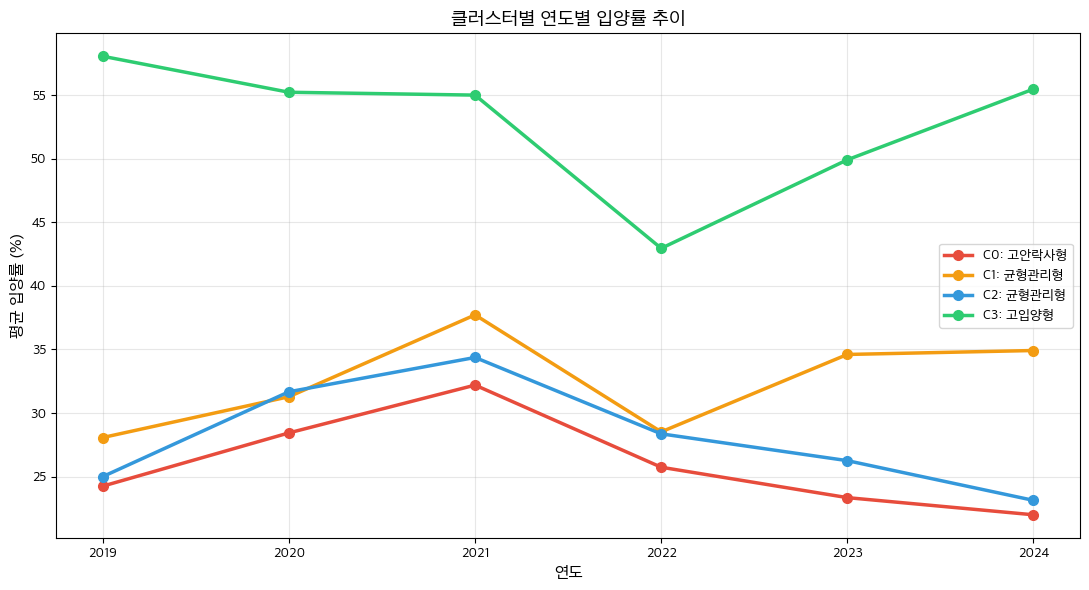

저장: cluster_yearly_trend.png


In [7]:
# ── 클러스터별 연도별 추이 ──
cluster_yearly = panel.dropna(subset=['cluster_v2_label']).groupby(
    ['cluster_v2_label', '접수년도'])['입양률'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
palette = {'C0: 고안락사형': '#e74c3c', 'C1: 균형관리형': '#f39c12',
           'C2: 균형관리형': '#3498db', 'C3: 고입양형': '#2ecc71'}

for label, group in cluster_yearly.groupby('cluster_v2_label'):
    color = palette.get(label, '#999999')
    ax.plot(group['접수년도'], group['입양률'], 'o-', color=color,
            linewidth=2.5, markersize=7, label=label)

ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('평균 입양률 (%)', fontsize=12)
ax.set_title('클러스터별 연도별 입양률 추이', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.set_xticks(sorted(panel['접수년도'].unique()))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cluster_yearly_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: cluster_yearly_trend.png")


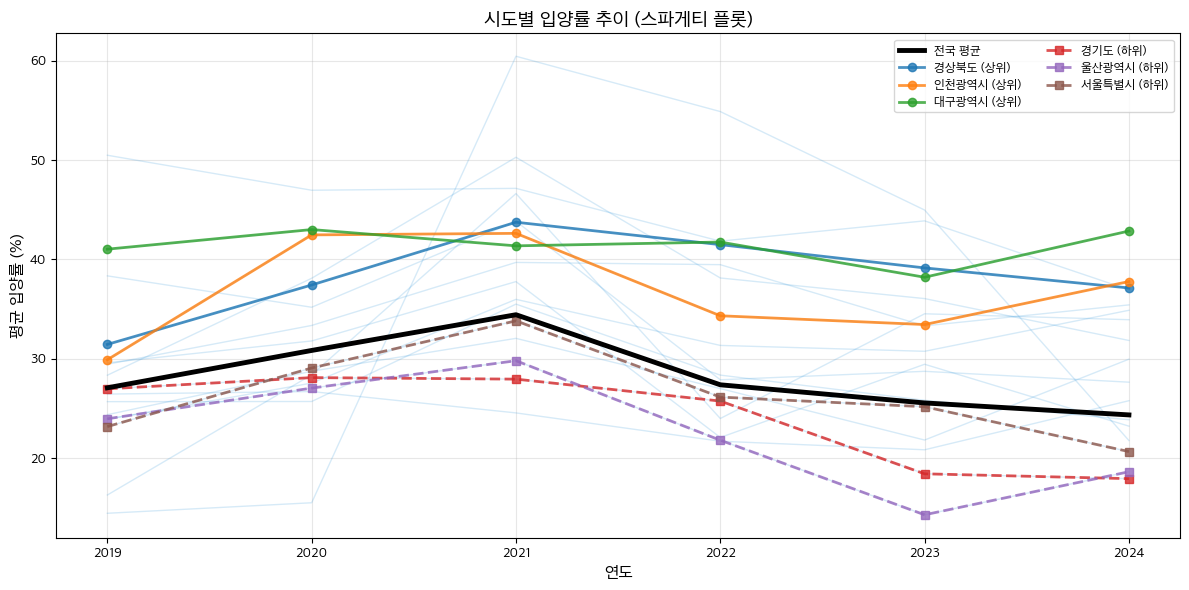

저장: sido_spaghetti.png


In [8]:
# ── 시도별 스파게티 플롯 ──
sido_yearly = panel.groupby(['시도', '접수년도'])['입양률'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
# 전국 평균
nat_mean = panel.groupby('접수년도')['입양률'].mean()
ax.plot(nat_mean.index, nat_mean.values, 'k-', linewidth=3.5, label='전국 평균', zorder=10)

# 시도별 (연한 색)
for sido in sido_yearly['시도'].unique():
    sub = sido_yearly[sido_yearly['시도'] == sido]
    ax.plot(sub['접수년도'], sub['입양률'], '-', color='#3498db', alpha=0.2, linewidth=1)

# 최고/최저 시도 강조
last_year = sido_yearly['접수년도'].max()
last_data = sido_yearly[sido_yearly['접수년도'] == last_year].sort_values('입양률')
top3 = last_data.tail(3)['시도'].values
bottom3 = last_data.head(3)['시도'].values

for sido in top3:
    sub = sido_yearly[sido_yearly['시도'] == sido]
    ax.plot(sub['접수년도'], sub['입양률'], 'o-', linewidth=2, alpha=0.8, label=f'{sido} (상위)')
for sido in bottom3:
    sub = sido_yearly[sido_yearly['시도'] == sido]
    ax.plot(sub['접수년도'], sub['입양률'], 's--', linewidth=2, alpha=0.8, label=f'{sido} (하위)')

ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('평균 입양률 (%)', fontsize=12)
ax.set_title('시도별 입양률 추이 (스파게티 플롯)', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='best', ncol=2)
ax.set_xticks(sorted(panel['접수년도'].unique()))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sido_spaghetti.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: sido_spaghetti.png")


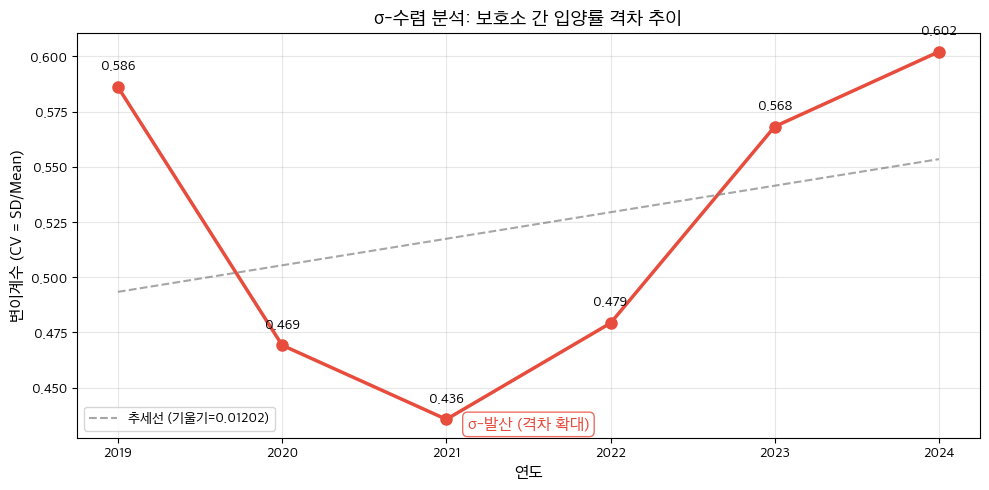

저장: convergence_cv.png

CV 변화: 0.5861 -> 0.6021
판정: σ-발산 (격차 확대)


In [9]:
# ── sigma-수렴 분석 (CV 추이) ──
cv_yearly = panel.groupby('접수년도')['입양률'].agg(['mean', 'std'])
cv_yearly['CV'] = cv_yearly['std'] / cv_yearly['mean']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cv_yearly.index, cv_yearly['CV'], 'o-', color='#e74c3c', linewidth=2.5, markersize=8)
for x, y in zip(cv_yearly.index, cv_yearly['CV']):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=10, fontweight='bold')

# 추세선
z = np.polyfit(cv_yearly.index, cv_yearly['CV'], 1)
p = np.poly1d(z)
ax.plot(cv_yearly.index, p(cv_yearly.index), '--', color='gray', linewidth=1.5, alpha=0.7,
        label=f'추세선 (기울기={z[0]:.5f})')

ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('변이계수 (CV = SD/Mean)', fontsize=12)
ax.set_title('σ-수렴 분석: 보호소 간 입양률 격차 추이', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xticks(cv_yearly.index)
ax.grid(True, alpha=0.3)

# 판정
cv_first = cv_yearly['CV'].iloc[0]
cv_last = cv_yearly['CV'].iloc[-1]
if cv_last < cv_first:
    verdict = "σ-수렴 확인 (격차 축소)"
    color = '#2ecc71'
else:
    verdict = "σ-발산 (격차 확대)"
    color = '#e74c3c'

ax.text(0.5, 0.02, verdict, transform=ax.transAxes, fontsize=12,
        fontweight='bold', color=color, ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'convergence_cv.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: convergence_cv.png")
print(f"\nCV 변화: {cv_first:.4f} -> {cv_last:.4f}")
print(f"판정: {verdict}")


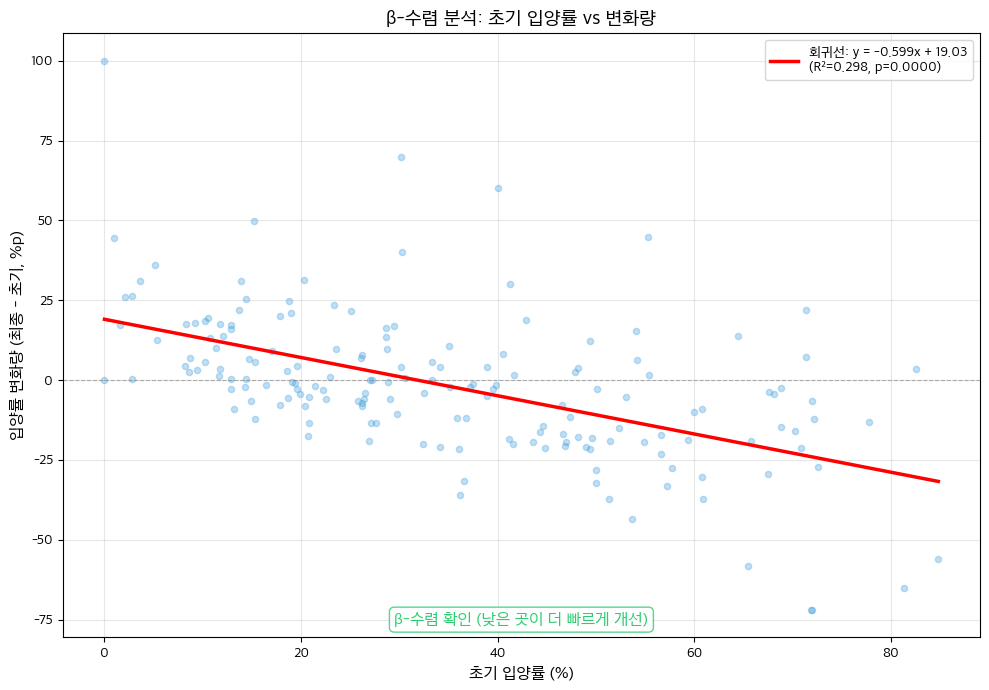

저장: convergence_beta.png

기울기(β): -0.5985, p-value: 0.0000
분석 대상 보호소 수: 173


In [10]:
# ── beta-수렴 분석 ──
years = sorted(panel['접수년도'].unique())
first_year, last_year_val = years[0], years[-1]

# 보호소별 첫해/마지막해 입양률 (중복 보호소명 평균 처리)
shelter_first = panel[panel['접수년도'] == first_year].groupby('보호소명')['입양률'].mean()
shelter_last = panel[panel['접수년도'] == last_year_val].groupby('보호소명')['입양률'].mean()

# 양쪽 모두 존재하는 보호소만
common = shelter_first.index.intersection(shelter_last.index)
beta_df = pd.DataFrame({
    '초기_입양률': shelter_first.loc[common].values,
    '최종_입양률': shelter_last.loc[common].values
}, index=common)
beta_df['변화량'] = beta_df['최종_입양률'] - beta_df['초기_입양률']

slope, intercept, r_value, p_value, std_err = stats.linregress(
    beta_df['초기_입양률'], beta_df['변화량'])

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(beta_df['초기_입양률'], beta_df['변화량'], alpha=0.3, s=20, color='#3498db', zorder=2)

x_line = np.linspace(beta_df['초기_입양률'].min(), beta_df['초기_입양률'].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r-', linewidth=2.5, zorder=3,
        label=f'회귀선: y = {slope:.3f}x + {intercept:.2f}\n(R²={r_value**2:.3f}, p={p_value:.4f})')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('초기 입양률 (%)', fontsize=12)
ax.set_ylabel('입양률 변화량 (최종 - 초기, %p)', fontsize=12)
ax.set_title('β-수렴 분석: 초기 입양률 vs 변화량', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

if slope < 0 and p_value < 0.05:
    verdict_beta = "β-수렴 확인 (낮은 곳이 더 빠르게 개선)"
    vc = '#2ecc71'
elif slope < 0:
    verdict_beta = f"β-수렴 경향 (통계적 비유의, p={p_value:.3f})"
    vc = '#f39c12'
else:
    verdict_beta = "β-수렴 미확인 (발산 경향)"
    vc = '#e74c3c'

ax.text(0.5, 0.02, verdict_beta, transform=ax.transAxes, fontsize=12,
        fontweight='bold', color=vc, ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=vc, alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'convergence_beta.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: convergence_beta.png")
print(f"\n기울기(β): {slope:.4f}, p-value: {p_value:.4f}")
print(f"분석 대상 보호소 수: {len(beta_df)}")


## 4. 고정효과 모델 (Fixed Effects)

보호소 고정효과를 통해 관측되지 않은 보호소 특성(시설, 문화 등)을 통제하고, **시간에 따른 변화**만을 포착합니다.

- **Pooled OLS:** 패널 구조 무시
- **Entity FE (보호소 고정효과):** 보호소 내 평균 차감 (within transformation)
- **Two-way FE (보호소 + 연도):** 연도 공통 트렌드 통제

In [11]:
# ── Pooled OLS ──
dep_var = '입양률'
indep_vars = ['안락사율', '자연사율', '개비율', '평균보호기간',
              '인구밀도', '재정자립도', '고령화율', '1인가구비율']

panel_ols = panel.dropna(subset=[dep_var] + indep_vars).copy()
print(f"Pooled OLS 분석 데이터: {len(panel_ols):,}행 (결측 제거 후)")

X_pooled = sm.add_constant(panel_ols[indep_vars])
y_pooled = panel_ols[dep_var]

model_pooled = sm.OLS(y_pooled, X_pooled).fit()
print("\n" + "=" * 70)
print("Pooled OLS 결과")
print("=" * 70)
print(model_pooled.summary().tables[0])
print()
print(model_pooled.summary().tables[1])
print(f"\nR² = {model_pooled.rsquared:.4f}, Adj. R² = {model_pooled.rsquared_adj:.4f}")


Pooled OLS 분석 데이터: 12,509행 (결측 제거 후)

Pooled OLS 결과
                            OLS Regression Results                            
Dep. Variable:                    입양률   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     1648.
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:04:00   Log-Likelihood:                -46847.
No. Observations:               12509   AIC:                         9.371e+04
Df Residuals:                   12500   BIC:                         9.378e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [12]:
# ── Entity Fixed Effects (Within Transformation) ──
shelter_counts = panel_ols.groupby('보호소명').size()
valid_shelters = shelter_counts[shelter_counts >= 2].index
panel_fe = panel_ols[panel_ols['보호소명'].isin(valid_shelters)].copy()
print(f"Entity FE 분석: {len(panel_fe):,}행 (2년+ 보호소: {len(valid_shelters)}개)")

fe_vars = [dep_var] + indep_vars
for var in fe_vars:
    shelter_mean = panel_fe.groupby('보호소명')[var].transform('mean')
    panel_fe[f'{var}_dm'] = panel_fe[var] - shelter_mean

dm_indep = [f'{v}_dm' for v in indep_vars]
dm_dep = f'{dep_var}_dm'

panel_fe_clean = panel_fe.dropna(subset=[dm_dep] + dm_indep)

X_fe = panel_fe_clean[dm_indep]
y_fe = panel_fe_clean[dm_dep]

model_fe = sm.OLS(y_fe, X_fe).fit()

print("\n" + "=" * 70)
print("Entity Fixed Effects (Within Transformation)")
print("=" * 70)
print(model_fe.summary().tables[0])
print()
print(model_fe.summary().tables[1])
print(f"\nWithin R² = {model_fe.rsquared:.4f}")
print(f"Pooled OLS R² = {model_pooled.rsquared:.4f}")


Entity FE 분석: 12,436행 (2년+ 보호소: 352개)



Entity Fixed Effects (Within Transformation)
                                 OLS Regression Results                                
Dep. Variable:                 입양률_dm   R-squared (uncentered):                   0.514
Model:                            OLS   Adj. R-squared (uncentered):              0.514
Method:                 Least Squares   F-statistic:                              1642.
Date:                Tue, 24 Mar 2026   Prob (F-statistic):                        0.00
Time:                        13:04:00   Log-Likelihood:                         -40176.
No. Observations:               12436   AIC:                                  8.037e+04
Df Residuals:                   12428   BIC:                                  8.043e+04
Df Model:                           8                                                  
Covariance Type:            nonrobust                                                  

                 coef    std err          t      P>|t|      [0.025      

In [13]:
# ── Two-way FE (보호소 + 연도) ──
year_dummies = pd.get_dummies(panel_fe_clean['접수년도'], prefix='Y', drop_first=True, dtype=float)

X_twoway = pd.concat([panel_fe_clean[dm_indep].reset_index(drop=True),
                       year_dummies.reset_index(drop=True)], axis=1)
y_twoway = panel_fe_clean[dm_dep].reset_index(drop=True)

model_twoway = sm.OLS(y_twoway, X_twoway).fit()

print("=" * 70)
print("Two-way FE (보호소 + 연도 고정효과)")
print("=" * 70)
print(model_twoway.summary().tables[0])
print()
print(model_twoway.summary().tables[1])
print(f"\nTwo-way FE R² = {model_twoway.rsquared:.4f}")
print(f"Entity FE R² = {model_fe.rsquared:.4f}")
print(f"Pooled OLS R² = {model_pooled.rsquared:.4f}")


Two-way FE (보호소 + 연도 고정효과)
                                 OLS Regression Results                                
Dep. Variable:                 입양률_dm   R-squared (uncentered):                   0.551
Model:                            OLS   Adj. R-squared (uncentered):              0.551
Method:                 Least Squares   F-statistic:                              1173.
Date:                Tue, 24 Mar 2026   Prob (F-statistic):                        0.00
Time:                        13:04:00   Log-Likelihood:                         -39682.
No. Observations:               12436   AIC:                                  7.939e+04
Df Residuals:                   12423   BIC:                                  7.949e+04
Df Model:                          13                                                  
Covariance Type:            nonrobust                                                  

                 coef    std err          t      P>|t|      [0.025      0.975]
-------------

모델 비교 요약표


,모델,R²,Adj_R²,관측치,β_안락사율,β_자연사율,β_개비율,β_평균보호기간
0,Pooled OLS,0.5133,0.5130,12509,-0.6124,-0.5930,-0.1426,-0.0229
1,Entity FE,0.5139,0.5136,12436,-0.5014,-0.6560,-0.1178,0.1751
2,Two-way FE,0.5510,0.5505,12436,-0.4719,-0.6172,-0.1232,0.1121


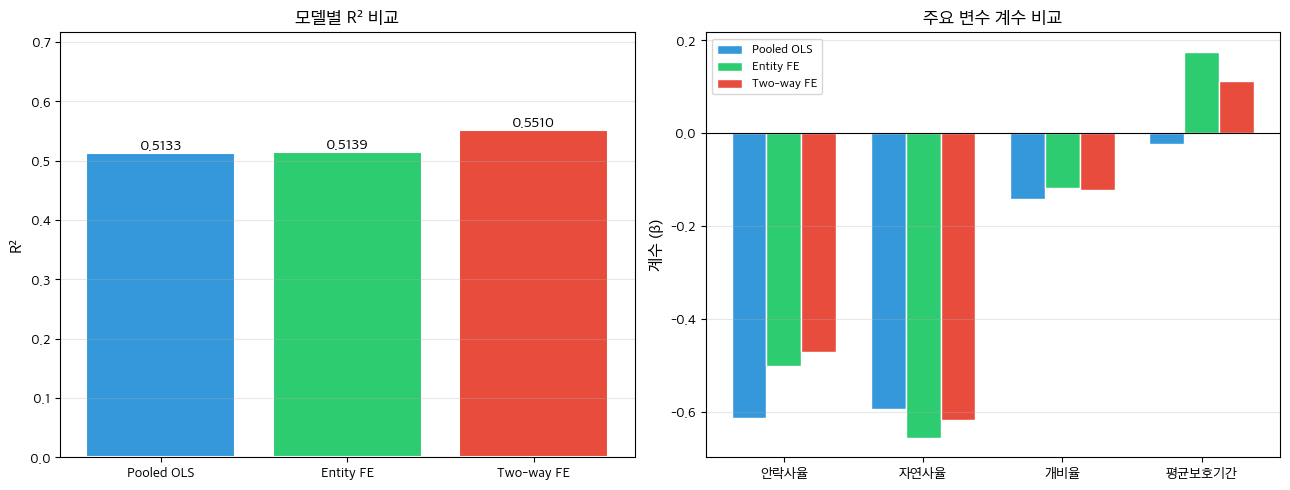

저장: fe_model_comparison.png


In [14]:
# ── 모델 비교 시각화 ──
comparison = pd.DataFrame({
    '모델': ['Pooled OLS', 'Entity FE', 'Two-way FE'],
    'R²': [model_pooled.rsquared, model_fe.rsquared, model_twoway.rsquared],
    'Adj_R²': [model_pooled.rsquared_adj, model_fe.rsquared_adj, model_twoway.rsquared_adj],
    '관측치': [int(model_pooled.nobs), int(model_fe.nobs), int(model_twoway.nobs)]
})

key_vars_display = indep_vars[:4]
for var in key_vars_display:
    pooled_coef = model_pooled.params.get(var, np.nan)
    fe_coef = model_fe.params.get(f'{var}_dm', np.nan)
    twoway_coef = model_twoway.params.get(f'{var}_dm', np.nan)
    comparison[f'β_{var}'] = [pooled_coef, fe_coef, twoway_coef]

print("=" * 70)
print("모델 비교 요약표")
print("=" * 70)
display(comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_bar = ['#3498db', '#2ecc71', '#e74c3c']

# R² 비교
ax1 = axes[0]
bars = ax1.bar(comparison['모델'], comparison['R²'], color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, comparison['R²']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax1.set_ylabel('R²', fontsize=12)
ax1.set_title('모델별 R² 비교', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(comparison['R²']) * 1.3)
ax1.grid(axis='y', alpha=0.3)

# 계수 비교
ax2 = axes[1]
x_pos = np.arange(len(key_vars_display))
width = 0.25
for i, (mn, c) in enumerate(zip(['Pooled OLS', 'Entity FE', 'Two-way FE'], colors_bar)):
    vals = [comparison[comparison['모델'] == mn][f'β_{v}'].values[0] for v in key_vars_display]
    ax2.bar(x_pos + i * width, vals, width, label=mn, color=c, edgecolor='white')
ax2.set_xticks(x_pos + width)
ax2.set_xticklabels(key_vars_display, fontsize=10)
ax2.set_ylabel('계수 (β)', fontsize=12)
ax2.set_title('주요 변수 계수 비교', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fe_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: fe_model_comparison.png")


## 5. 시차 효과 분석 (Lagged Effects)

사회경제 변수의 **시차 효과**를 분석합니다:
- Granger 인과검정: "X의 과거값이 Y의 예측에 도움이 되는가?"
- 지연변수 회귀: t-1기 사회경제 변수 → t기 입양률

In [15]:
# ── Granger 인과검정 ──
from statsmodels.tsa.stattools import grangercausalitytests

print("=" * 70)
print("Granger 인과검정")
print("=" * 70)

# 전국 집계
national_adoption = df_region.groupby('접수년도')['입양률'].mean().reset_index().sort_values('접수년도')
national_socio = df_socio.groupby('연도')[['고령화율', '1인가구비율', '인구밀도']].mean().reset_index()
national_ts = national_adoption.merge(national_socio, left_on='접수년도', right_on='연도', how='inner')
print(f"전국 시계열 길이: {len(national_ts)}년")
print(national_ts[['접수년도', '입양률', '고령화율', '1인가구비율', '인구밀도']].to_string(index=False))

test_vars = ['고령화율', '1인가구비율', '인구밀도']
granger_results = []

print("\n--- Granger 인과검정 (maxlag=1) ---")
for var in test_vars:
    ts_data = national_ts[['입양률', var]].dropna()
    if len(ts_data) >= 4:
        try:
            result = grangercausalitytests(ts_data.values, maxlag=1, verbose=False)
            for lag in result:
                f_stat = result[lag][0]['ssr_ftest'][0]
                p_val = result[lag][0]['ssr_ftest'][1]
                granger_results.append({
                    '변수': var, 'lag': lag, 'F-통계량': round(f_stat, 4),
                    'p-value': round(p_val, 4), '유의': '예' if p_val < 0.05 else '아니오'
                })
                print(f"  {var} -> 입양률 (lag={lag}): F={f_stat:.4f}, p={p_val:.4f}")
        except Exception as e:
            print(f"  {var}: {e}")
            granger_results.append({'변수': var, 'lag': 1, 'F-통계량': np.nan, 'p-value': np.nan, '유의': '검정불가'})
    else:
        granger_results.append({'변수': var, 'lag': 1, 'F-통계량': np.nan, 'p-value': np.nan, '유의': '데이터부족'})

# 시도별 시차 상관
print("\n--- 시도별 시차 상관분석 ---")
sido_panel = df_region.merge(
    df_socio.groupby(['시도', '연도'])[['고령화율', '1인가구비율', '인구밀도']].mean().reset_index(),
    left_on=['시도', '접수년도'], right_on=['시도', '연도'], how='inner'
)

lag_corr_results = []
for var in test_vars:
    sido_sorted = sido_panel.sort_values(['시도', '접수년도'])
    sido_sorted[f'{var}_lag1'] = sido_sorted.groupby('시도')[var].shift(1)
    valid = sido_sorted.dropna(subset=[f'{var}_lag1', '입양률'])
    if len(valid) >= 5:
        corr, pv = stats.pearsonr(valid[f'{var}_lag1'], valid['입양률'])
        print(f"  {var}(t-1) <-> 입양률(t): r={corr:.4f}, p={pv:.4f} (n={len(valid)})")
        lag_corr_results.append({'변수': f'{var}(t-1)', '상관계수': round(corr, 4),
                                  'p-value': round(pv, 4), '유의': '예' if pv < 0.05 else '아니오', 'N': len(valid)})

granger_df = pd.DataFrame(granger_results)
lag_corr_df = pd.DataFrame(lag_corr_results)
display(granger_df)
display(lag_corr_df)


Granger 인과검정
전국 시계열 길이: 6년
 접수년도       입양률      고령화율    1인가구비율        인구밀도
 2019 29.994118 20.553679 31.876288 3369.307308
 2020 33.285882 21.342943 33.307960 3816.760526
 2021 36.548235 22.366421 34.992977 3767.106579
 2022 31.002353 23.522074 35.979298 3740.271930
 2023 27.915294 24.475452 37.038629 3745.699559
 2024 28.046471 25.631037 37.630602 3732.174890

--- Granger 인과검정 (maxlag=1) ---
  고령화율 -> 입양률 (lag=1): F=4.3723, p=0.1717
  1인가구비율 -> 입양률 (lag=1): F=4.1698, p=0.1779
  인구밀도 -> 입양률 (lag=1): F=0.2141, p=0.6890

--- 시도별 시차 상관분석 ---
  고령화율(t-1) <-> 입양률(t): r=0.0513, p=0.6621 (n=75)
  1인가구비율(t-1) <-> 입양률(t): r=0.0687, p=0.5583 (n=75)
  인구밀도(t-1) <-> 입양률(t): r=0.0543, p=0.6550 (n=70)


,변수,lag,F-통계량,p-value,유의
0,고령화율,1,4.3723,0.1717,아니오
1,1인가구비율,1,4.1698,0.1779,아니오
2,인구밀도,1,0.2141,0.6890,아니오


,변수,상관계수,p-value,유의,N
0,고령화율(t-1),0.0513,0.6621,아니오,75
1,1인가구비율(t-1),0.0687,0.5583,아니오,75
2,인구밀도(t-1),0.0543,0.6550,아니오,70


In [16]:
# ── 지연변수 회귀 ──
panel_lag = panel.sort_values(['보호소명', '접수년도']).copy()
lag_vars = ['고령화율', '1인가구비율', '인구밀도']
for var in lag_vars:
    panel_lag[f'L1_{var}'] = panel_lag.groupby('보호소명')[var].shift(1)

current_controls = ['안락사율', '자연사율', '개비율', '평균보호기간']
lag_indep = [f'L1_{v}' for v in lag_vars]
all_vars = current_controls + lag_indep

panel_lag_clean = panel_lag.dropna(subset=['입양률'] + all_vars)
print(f"지연변수 회귀 분석 데이터: {len(panel_lag_clean):,}행")

X_lag = sm.add_constant(panel_lag_clean[all_vars])
y_lag = panel_lag_clean['입양률']
model_lag = sm.OLS(y_lag, X_lag).fit()

print("\n" + "=" * 70)
print("지연변수 회귀: 입양률 ~ 현재 통제 + L1(사회경제)")
print("=" * 70)
print(model_lag.summary().tables[1])

print("\n--- 시차 vs 동시 효과 ---")
for var in lag_vars:
    lag_c = model_lag.params.get(f'L1_{var}', np.nan)
    lag_pv = model_lag.pvalues.get(f'L1_{var}', np.nan)
    pooled_c = model_pooled.params.get(var, np.nan)
    pooled_pv = model_pooled.pvalues.get(var, np.nan)
    print(f"  {var}: 동시 β={pooled_c:.4f}(p={pooled_pv:.4f}), 시차 β={lag_c:.4f}(p={lag_pv:.4f})")


지연변수 회귀 분석 데이터: 12,113행

지연변수 회귀: 입양률 ~ 현재 통제 + L1(사회경제)
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         71.4859      0.906     78.912      0.000      69.710      73.262
안락사율          -0.5898      0.007    -79.133      0.000      -0.604      -0.575
자연사율          -0.5766      0.006    -92.522      0.000      -0.589      -0.564
개비율           -0.1499      0.006    -26.468      0.000      -0.161      -0.139
평균보호기간        -0.0187      0.052     -0.360      0.719      -0.121       0.083
L1_고령화율        0.3071      0.021     14.658      0.000       0.266       0.348
L1_1인가구비율     -0.2034      0.018    -11.116      0.000      -0.239      -0.168
L1_인구밀도       -0.0005   1.52e-05    -34.540      0.000      -0.001      -0.000

--- 시차 vs 동시 효과 ---
  고령화율: 동시 β=0.2777(p=0.0000), 시차 β=0.3071(p=0.0000)
  1인가구비율: 동시 β=-0.1977(p=0.0000), 시차 β=-0.2034(p=0.0000)
  인구밀도: 동시 β=-0.0006(p

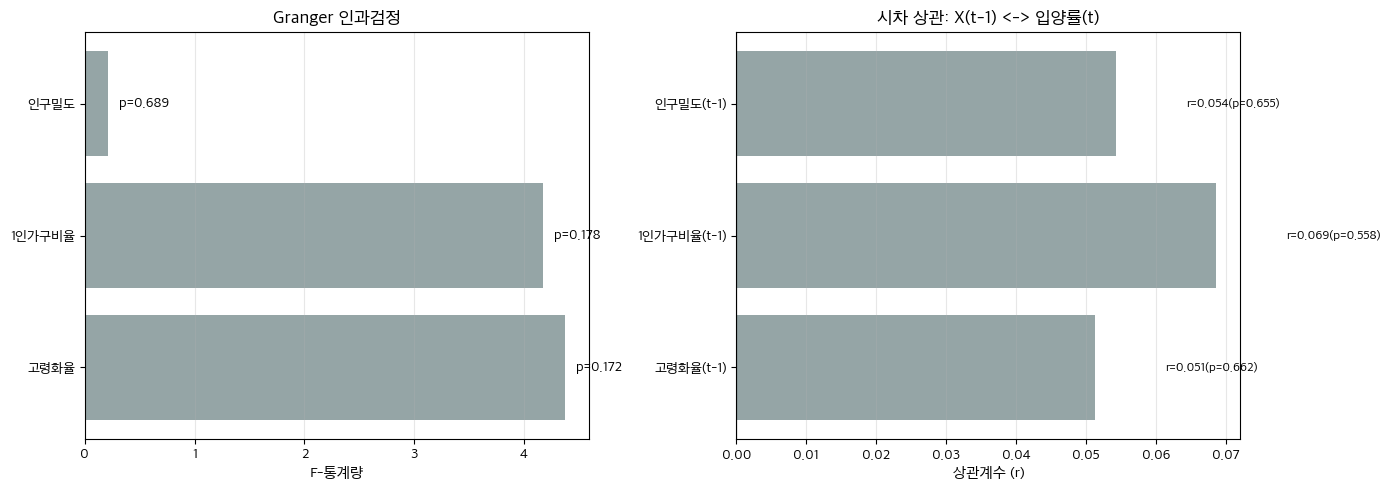

저장: granger_results.png


In [17]:
# ── Granger / 시차 결과 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
if len(granger_df) > 0 and granger_df['F-통계량'].notna().any():
    gdf = granger_df.dropna(subset=['F-통계량'])
    colors_g = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in gdf['p-value']]
    ax1.barh(gdf['변수'], gdf['F-통계량'], color=colors_g)
    for i, (f_v, p_v) in enumerate(zip(gdf['F-통계량'], gdf['p-value'])):
        ax1.text(f_v + 0.1, i, f'p={p_v:.3f}', va='center', fontsize=10)
    ax1.set_xlabel('F-통계량', fontsize=11)
else:
    ax1.text(0.5, 0.5, '검정 불가', ha='center', va='center', transform=ax1.transAxes, fontsize=12)
ax1.set_title('Granger 인과검정', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

ax2 = axes[1]
if len(lag_corr_df) > 0:
    colors_c = ['#2ecc71' if p < 0.05 else '#95a5a6' for p in lag_corr_df['p-value']]
    ax2.barh(lag_corr_df['변수'], lag_corr_df['상관계수'], color=colors_c)
    ax2.axvline(0, color='black', linewidth=0.8)
    for i, (r_v, p_v) in enumerate(zip(lag_corr_df['상관계수'], lag_corr_df['p-value'])):
        offset = 0.01 if r_v >= 0 else -0.01
        ax2.text(r_v + offset, i, f'r={r_v:.3f}(p={p_v:.3f})', va='center',
                 ha='left' if r_v >= 0 else 'right', fontsize=9)
ax2.set_xlabel('상관계수 (r)', fontsize=11)
ax2.set_title('시차 상관: X(t-1) <-> 입양률(t)', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'granger_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: granger_results.png")


## 6. DID 분석 — 입양률 변화의 전후 비교

**설계:** 수의사 배치 여부(시간불변)별로 전기(2019-2021)와 후기(2022-2024)의 입양률 변화를 비교합니다.

In [18]:
# ── Pseudo-DID 설계 ──
panel_did = panel.dropna(subset=['수의사유무', '입양률']).copy()
panel_did['수의사유무'] = panel_did['수의사유무'].astype(int)
panel_did['post'] = (panel_did['접수년도'] >= 2022).astype(int)

print("DID 데이터 구성:")
print(f"  전체: {len(panel_did):,}")
print(f"  처치(수의사O): {(panel_did['수의사유무']==1).sum():,}")
print(f"  대조(수의사X): {(panel_did['수의사유무']==0).sum():,}")

# 2x2 테이블
did_table = panel_did.groupby(['수의사유무', 'post'])['입양률'].mean().unstack()
did_table.index = ['수의사 X', '수의사 O']
did_table.columns = ['전기(2019-2021)', '후기(2022-2024)']
did_table['차이(후-전)'] = did_table['후기(2022-2024)'] - did_table['전기(2019-2021)']
print("\n--- DID 2x2 테이블 ---")
display(did_table.round(2))

did_estimate = (did_table.loc['수의사 O', '차이(후-전)'] -
                did_table.loc['수의사 X', '차이(후-전)'])
print(f"\nDID 추정치: {did_estimate:.2f}%p")

# OLS DID
panel_did['treat_post'] = panel_did['수의사유무'] * panel_did['post']
did_controls = ['안락사율', '자연사율', '개비율', '평균보호기간']
avail_ctrl = [c for c in did_controls if c in panel_did.columns]
panel_did_clean = panel_did.dropna(subset=['입양률', '수의사유무', 'post', 'treat_post'] + avail_ctrl)

X_did = sm.add_constant(panel_did_clean[['수의사유무', 'post', 'treat_post'] + avail_ctrl])
y_did = panel_did_clean['입양률']

model_did = sm.OLS(y_did, X_did).fit(cov_type='cluster', cov_kwds={'groups': panel_did_clean['보호소명']})

print("\n" + "=" * 70)
print("DID 회귀 결과 (클러스터 SE)")
print("=" * 70)
print(model_did.summary().tables[1])

did_coef = model_did.params['treat_post']
did_se = model_did.bse['treat_post']
did_ci = model_did.conf_int().loc['treat_post']
did_p = model_did.pvalues['treat_post']

print(f"\n--- DID 핵심 ---")
print(f"  계수: {did_coef:.4f}, SE: {did_se:.4f}")
print(f"  95% CI: [{did_ci.iloc[0]:.4f}, {did_ci.iloc[1]:.4f}]")
print(f"  p: {did_p:.4f} ({'유의' if did_p < 0.05 else '비유의'})")


DID 데이터 구성:
  전체: 12,853
  처치(수의사O): 10,725
  대조(수의사X): 2,128

--- DID 2x2 테이블 ---


,전기(2019-2021),후기(2022-2024),차이(후-전)
수의사 X,31.29,24.99,-6.3
수의사 O,30.71,25.91,-4.8



DID 추정치: 1.50%p

DID 회귀 결과 (클러스터 SE)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.0576      6.682      9.886      0.000      52.961      79.154
수의사유무         -0.4866      3.840     -0.127      0.899      -8.013       7.040
post          -5.6834      4.221     -1.346      0.178     -13.957       2.590
treat_post     1.8517      4.167      0.444      0.657      -6.316      10.019
안락사율          -0.5585      0.074     -7.534      0.000      -0.704      -0.413
자연사율          -0.5239      0.097     -5.388      0.000      -0.715      -0.333
개비율           -0.0735      0.040     -1.830      0.067      -0.152       0.005
평균보호기간        -0.3849      0.204     -1.889      0.059      -0.784       0.014

--- DID 핵심 ---
  계수: 1.8517, SE: 4.1671
  95% CI: [-6.3158, 10.0191]
  p: 0.6568 (비유의)


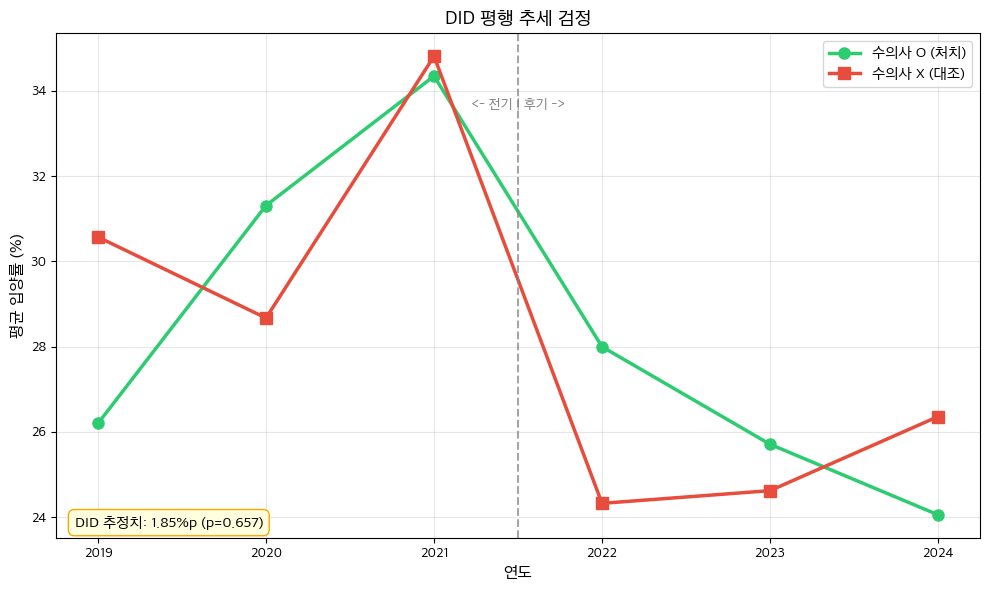

저장: did_parallel_trends.png


In [19]:
# ── 평행 추세 시각화 ──
pt = panel_did.groupby(['수의사유무', '접수년도'])['입양률'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
for grp, label, color, marker in [(1, '수의사 O (처치)', '#2ecc71', 'o'),
                                    (0, '수의사 X (대조)', '#e74c3c', 's')]:
    sub = pt[pt['수의사유무'] == grp].sort_values('접수년도')
    ax.plot(sub['접수년도'], sub['입양률'], f'{marker}-', color=color,
            linewidth=2.5, markersize=8, label=label)

ax.axvline(x=2021.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(2021.5, ax.get_ylim()[1] * 0.95, '<- 전기 | 후기 ->',
        ha='center', fontsize=10, color='gray', fontweight='bold')

ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('평균 입양률 (%)', fontsize=12)
ax.set_title('DID 평행 추세 검정', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(sorted(pt['접수년도'].unique()))
ax.grid(True, alpha=0.3)

ax.text(0.02, 0.02, f'DID 추정치: {did_coef:.2f}%p (p={did_p:.3f})',
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='orange'))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'did_parallel_trends.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: did_parallel_trends.png")


In [20]:
# ── DID 결과 해석 ──
print("=" * 70)
print("DID 분석 결과 해석")
print("=" * 70)

print(f"1. 설계: 수의사 배치(시간불변) x 전/후기(2022 기준)")
print(f"2. DID 계수: {did_coef:.4f}%p (p={did_p:.4f})")
print("3. 해석:")

if did_p < 0.05:
    print(f"   -> 수의사 배치 보호소는 후기에 대조군 대비 {abs(did_coef):.2f}%p 차별적 변화")
else:
    print(f"   -> DID 비유의 (p>0.05). 수의사 배치의 차별적 시간 효과 확인 불가")

print("4. 주의: 수의사유무는 시간불변 -> 순수 DID 해석 한계")
print("   평행 추세 가정의 시각적 확인 필요")


DID 분석 결과 해석
1. 설계: 수의사 배치(시간불변) x 전/후기(2022 기준)
2. DID 계수: 1.8517%p (p=0.6568)
3. 해석:
   -> DID 비유의 (p>0.05). 수의사 배치의 차별적 시간 효과 확인 불가
4. 주의: 수의사유무는 시간불변 -> 순수 DID 해석 한계
   평행 추세 가정의 시각적 확인 필요


## 7. 종합 결과

In [21]:
# ── 종합 결과 요약 ──
print("=" * 70)
print("10. 시계열 패널 분석 — 종합 결과")
print("=" * 70)

print(f"\n[1] σ-수렴: CV {cv_first:.4f} -> {cv_last:.4f} ({'수렴' if cv_last < cv_first else '발산'})")
print(f"[2] β-수렴: 기울기={slope:.4f}, p={p_value:.4f}")
print(f"[3] Pooled OLS R²={model_pooled.rsquared:.4f}")
print(f"    Entity FE R²={model_fe.rsquared:.4f}")
print(f"    Two-way FE R²={model_twoway.rsquared:.4f}")

for var in lag_vars:
    lc = model_lag.params.get(f'L1_{var}', np.nan)
    lp = model_lag.pvalues.get(f'L1_{var}', np.nan)
    sig = '***' if lp < 0.01 else ('**' if lp < 0.05 else ('*' if lp < 0.1 else ''))
    print(f"[4] L1_{var}: β={lc:.4f}, p={lp:.4f} {sig}")

print(f"[5] DID 계수: {did_coef:.4f} (p={did_p:.4f})")

summary_df = pd.DataFrame([
    {'분석': 'σ-수렴', '지표': 'CV 변화', '값': f'{cv_first:.4f} -> {cv_last:.4f}',
     '판정': '수렴' if cv_last < cv_first else '발산'},
    {'분석': 'β-수렴', '지표': '기울기(p)', '값': f'{slope:.4f} (p={p_value:.4f})',
     '판정': '유의' if p_value < 0.05 else '비유의'},
    {'분석': 'Pooled OLS', '지표': 'R²', '값': f'{model_pooled.rsquared:.4f}', '판정': '-'},
    {'분석': 'Entity FE', '지표': 'Within R²', '값': f'{model_fe.rsquared:.4f}', '판정': '-'},
    {'분석': 'Two-way FE', '지표': 'R²', '값': f'{model_twoway.rsquared:.4f}', '판정': '-'},
    {'분석': 'DID', '지표': 'DID 계수', '값': f'{did_coef:.4f} (p={did_p:.4f})',
     '판정': '유의' if did_p < 0.05 else '비유의'},
])
display(summary_df)


10. 시계열 패널 분석 — 종합 결과

[1] σ-수렴: CV 0.5861 -> 0.6021 (발산)
[2] β-수렴: 기울기=-0.5985, p=0.0000
[3] Pooled OLS R²=0.5133
    Entity FE R²=0.5139
    Two-way FE R²=0.5510
[4] L1_고령화율: β=0.3071, p=0.0000 ***
[4] L1_1인가구비율: β=-0.2034, p=0.0000 ***
[4] L1_인구밀도: β=-0.0005, p=0.0000 ***
[5] DID 계수: 1.8517 (p=0.6568)


,분석,지표,값,판정
0,σ-수렴,CV 변화,0.5861 -> 0.6021,발산
1,β-수렴,기울기(p),-0.5985 (p=0.0000),유의
2,Pooled OLS,R²,0.5133,-
3,Entity FE,Within R²,0.5139,-
4,Two-way FE,R²,0.5510,-
5,DID,DID 계수,1.8517 (p=0.6568),비유의


### 정책 시사점

**시간에 따른 입양률 변화:**
- σ-수렴/발산 분석으로 보호소 간 격차 추이 확인
- β-수렴 분석으로 초기 입양률이 낮은 보호소의 개선 여부 확인

**고정효과 모델:**
- 보호소 간 차이를 통제하면 사회경제 변수의 "순수 효과" 추정 가능
- Pooled OLS → Entity FE → Two-way FE로 점진적 통제

**시차 효과:**
- 사회경제 변수의 t-1기 값이 t기 입양률에 미치는 지연 효과 분석

**DID:**
- 수의사 배치의 차별적 효과를 전후 비교로 추정
- 시간불변 처치에 대한 DID의 해석적 한계 인지

In [22]:
# ── 결과 저장 ──
results_data = {
    '분석항목': ['σ-수렴', 'β-수렴', 'Pooled OLS', 'Entity FE', 'Two-way FE', 'DID'],
    '세부내용': ['CV 변화', f'기울기(β)={slope:.4f}', 'R²', 'Within R²', 'R²', '수의사유무*post'],
    '값': [
        f'{cv_first:.4f} -> {cv_last:.4f}',
        f'p={p_value:.4f}',
        f'{model_pooled.rsquared:.4f}',
        f'{model_fe.rsquared:.4f}',
        f'{model_twoway.rsquared:.4f}',
        f'β={did_coef:.4f}, p={did_p:.4f}'
    ],
    '유의여부': [
        '수렴' if cv_last < cv_first else '발산',
        '유의' if p_value < 0.05 else '비유의',
        '-', '-', '-',
        '유의' if did_p < 0.05 else '비유의'
    ]
}

# 시차 효과 추가
for var in lag_vars:
    lc = model_lag.params.get(f'L1_{var}', np.nan)
    lp = model_lag.pvalues.get(f'L1_{var}', np.nan)
    results_data['분석항목'].append('시차효과')
    results_data['세부내용'].append(f'L1_{var}')
    results_data['값'].append(f'β={lc:.4f}, p={lp:.4f}')
    results_data['유의여부'].append('유의' if lp < 0.05 else '비유의')

results_df = pd.DataFrame(results_data)
results_path = os.path.join(DATA_DIR, 'panel_analysis_results.csv')
results_df.to_csv(results_path, index=False, encoding='utf-8-sig')
print(f"저장: {results_path}")
display(results_df)

# 파일 목록
print("\n" + "=" * 70)
print("저장된 파일")
print("=" * 70)
files = [
    os.path.join(DATA_DIR, 'shelter_yearly_panel.csv'),
    os.path.join(DATA_DIR, 'panel_analysis_results.csv'),
    os.path.join(FIG_DIR, 'national_yearly_trend.png'),
    os.path.join(FIG_DIR, 'cluster_yearly_trend.png'),
    os.path.join(FIG_DIR, 'sido_spaghetti.png'),
    os.path.join(FIG_DIR, 'convergence_cv.png'),
    os.path.join(FIG_DIR, 'convergence_beta.png'),
    os.path.join(FIG_DIR, 'fe_model_comparison.png'),
    os.path.join(FIG_DIR, 'granger_results.png'),
    os.path.join(FIG_DIR, 'did_parallel_trends.png'),
]
for f in files:
    status = 'O' if os.path.exists(f) else 'X'
    print(f"  [{status}] {f}")
print("\n분석 완료!")


저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data/panel_analysis_results.csv


,분석항목,세부내용,값,유의여부
0,σ-수렴,CV 변화,0.5861 -> 0.6021,발산
1,β-수렴,기울기(β)=-0.5985,p=0.0000,유의
2,Pooled OLS,R²,0.5133,-
3,Entity FE,Within R²,0.5139,-
4,Two-way FE,R²,0.5510,-
5,DID,수의사유무*post,"β=1.8517, p=0.6568",비유의
6,시차효과,L1_고령화율,"β=0.3071, p=0.0000",유의
7,시차효과,L1_1인가구비율,"β=-0.2034, p=0.0000",유의
8,시차효과,L1_인구밀도,"β=-0.0005, p=0.0000",유의



저장된 파일
  [O] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data/shelter_yearly_panel.csv
  [O] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data/panel_analysis_results.csv
  [O] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/panel/national_yearly_trend.png
  [O] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/panel/cluster_yearly_trend.png
  [O] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/panel/sido_spaghetti.png
  [O] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/panel/convergence_cv.png
  [O] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/panel/convergence_beta.png
  [O] /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/panel/fe_model_comparison.png
  [O] /Users/yu_seok/Documents/Document/workspace/03_프로젝